In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [68]:
home= "Milan"
away= "Lazio"

In [69]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Milan,Inter,2025-02-02,D,H,1,1,0,37,0,...,0.3,0.4,0.4,0.4,-0.3,0.06,0,1.6,0.28,0.6
22,Milan,Empoli,2025-02-08,W,A,2,0,2,61,0,...,1.1,0.6,0.7,0.7,0.9,0.08,1,0.0,NaN,0.0
23,Milan,Hellas Verona,2025-02-15,W,H,1,0,1,73,0,...,1.8,1.9,-1.1,-1.1,-0.8,0.12,0,0.7,0.34,0.7
24,Milan,Torino,2025-02-22,L,A,1,2,-1,64,1,...,1.2,1.4,-1.4,-0.6,-1.2,0.07,0,1.1,0.36,0.1
25,Milan,Bologna,2025-02-27,L,A,1,2,-1,43,0,...,0.8,0.3,0.2,0.2,0.2,0.10,0,1.7,0.43,-0.3


In [70]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Inter,Milan,2025-02-02,D,A,1,1,0,63,0,...,1.3,2.9,-0.3,-0.3,-0.3,0.08,0,1.0,0.25,0.0
22,Empoli,Milan,2025-02-08,L,H,0,2,-2,39,0,...,0.5,0.4,-0.7,-0.7,-0.5,0.09,0,1.3,0.26,-0.7
23,Hellas Verona,Milan,2025-02-15,L,A,0,1,-1,27,0,...,0.2,0.3,-0.4,-0.4,-0.2,0.05,1,1.4,0.47,0.4
24,Torino,Milan,2025-02-22,W,H,2,1,1,36,0,...,0.3,0.4,0.7,0.7,0.7,0.03,0,3.1,0.30,2.1
25,Bologna,Milan,2025-02-27,W,H,2,1,1,57,0,...,2.1,1.2,0.0,0.0,-0.1,0.15,0,1.2,0.29,0.2


In [71]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Lazio,Fiorentina,2025-01-26,L,H,1,2,-1,70,0,...,1.3,2.0,-0.4,-0.4,-0.3,0.06,1,1.2,0.38,-0.8
22,Lazio,Cagliari,2025-02-03,W,A,2,1,1,60,0,...,1.5,1.2,0.5,0.5,0.5,0.14,0,1.6,0.32,0.6
23,Lazio,Monza,2025-02-09,W,H,5,1,4,61,0,...,3.1,2.3,1.8,1.8,1.9,0.12,0,0.7,0.00,-0.3
24,Lazio,Napoli,2025-02-15,D,H,2,2,0,53,0,...,0.4,0.3,1.3,1.3,0.6,0.06,2,0.1,0.04,-0.9
25,Lazio,Venezia,2025-02-22,D,A,0,0,0,63,0,...,1.0,1.0,-1.1,-1.1,-1.0,0.12,0,0.8,0.39,0.8


In [72]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,Poss,PKatt,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
21,Fiorentina,Lazio,2025-01-26,W,A,2,1,1,30,0,...,0.7,0.7,1.3,1.3,1.3,0.10,0,1.0,0.34,0.0
22,Cagliari,Lazio,2025-02-03,L,H,1,2,-1,40,0,...,1.3,1.3,-0.6,-0.6,-0.3,0.11,0,2.8,0.47,0.8
23,Monza,Lazio,2025-02-09,L,A,1,5,-4,39,1,...,0.1,0.1,0.1,-0.1,-0.1,0.05,1,4.0,0.45,-1.0
24,Napoli,Lazio,2025-02-15,D,A,2,2,0,47,0,...,0.3,0.4,0.7,0.7,0.7,0.06,0,1.4,0.29,-0.6
25,Venezia,Lazio,2025-02-22,D,H,0,0,0,37,0,...,0.7,0.5,-0.8,-0.8,-0.7,0.09,0,0.4,0.14,0.4


In [73]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'Poss', 'PKatt', 'G-PK', 'PK', 'PKm', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [74]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [75]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,37,0,12,5,41.7,7,58.3,...,-0.7,-0.7,0.3,0.4,0.4,0.4,-0.3,0.06,0,1
22,2,0,0,61,0,25,12,48.0,13,52.0,...,0.6,0.6,1.1,0.6,0.7,0.7,0.9,0.08,1,2
23,1,0,0,73,0,21,13,61.9,7,33.3,...,1.8,1.8,1.8,1.9,-1.1,-1.1,-0.8,0.12,0,1
24,1,0,1,64,1,14,4,28.6,5,35.7,...,2.1,1.3,1.2,1.4,-1.4,-0.6,-1.2,0.07,0,1
25,1,0,0,43,0,14,8,57.1,5,35.7,...,-1.3,-1.3,0.8,0.3,0.2,0.2,0.2,0.10,0,1


In [76]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,63,0,12,6,50.0,6,50.0,...,0.7,0.7,1.3,2.9,-0.3,-0.3,-0.3,0.08,0,1
22,0,0,0,39,0,16,6,37.5,9,56.3,...,-0.6,-0.6,0.5,0.4,-0.7,-0.7,-0.5,0.09,0,0
23,0,0,0,27,0,9,5,55.6,3,33.3,...,-1.8,-1.8,0.2,0.3,-0.4,-0.4,-0.2,0.05,1,0
24,1,0,0,36,0,10,4,40.0,5,50.0,...,-2.1,-1.3,0.3,0.4,0.7,0.7,0.7,0.03,0,2
25,2,0,0,57,0,14,7,50.0,6,42.9,...,1.3,1.3,2.1,1.2,0.0,0.0,-0.1,0.15,0,2


In [77]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,1,0,0,70,0,24,10,41.7,13,54.2,...,0.6,0.6,1.3,2.0,-0.4,-0.4,-0.3,0.06,1,1
22,2,0,0,60,0,14,6,42.9,7,50.0,...,-0.1,-0.1,1.5,1.2,0.5,0.5,0.5,0.14,0,2
23,5,0,0,61,0,16,9,56.3,5,31.3,...,2.3,3.1,3.1,2.3,1.8,1.8,1.9,0.12,0,5
24,2,0,0,53,0,20,10,50.0,10,50.0,...,0.4,0.4,0.4,0.3,1.3,1.3,0.6,0.06,2,2
25,0,0,0,63,0,26,14,53.8,9,34.6,...,0.3,0.3,1.0,1.0,-1.1,-1.1,-1.0,0.12,0,0


In [78]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
21,2,0,0,30,0,14,6,42.9,8,57.1,...,-0.6,-0.6,0.7,0.7,1.3,1.3,1.3,0.10,0,2
22,1,0,0,40,0,11,4,36.4,7,63.6,...,0.1,0.1,1.3,1.3,-0.6,-0.6,-0.3,0.11,0,1
23,0,1,0,39,1,14,8,57.1,5,35.7,...,-2.3,-3.1,0.1,0.1,0.1,-0.1,-0.1,0.05,1,1
24,1,0,0,47,0,3,1,33.3,1,33.3,...,-0.4,-0.4,0.3,0.4,0.7,0.7,0.7,0.06,0,2
25,0,0,0,37,0,14,8,57.1,4,28.6,...,-0.3,-0.3,0.7,0.5,-0.8,-0.8,-0.7,0.09,0,0


## Defence

In [79]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [80]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
21,25,0,0.0,0,2,26.0,0,NaN,0,0,...,3,5,13,33,19,1,1.6,0.28,0.6,1
22,12,1,8.3,0,5,27.8,0,NaN,0,0,...,4,5,7,25,25,0,0.0,NaN,0.0,0
23,10,2,20.0,0,1,12.5,0,NaN,0,0,...,2,3,4,13,18,0,0.7,0.34,0.7,0
24,11,1,9.1,0,4,19.5,0,NaN,0,0,...,2,3,4,15,25,1,1.1,0.36,0.1,2
25,11,0,0.0,0,3,30.5,0,NaN,0,0,...,3,3,13,33,25,0,1.7,0.43,-0.3,2


In [81]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
21,6,0,0.0,0,0,9.0,0,NaN,0,0,...,5,5,6,14,15,0,1.0,0.25,0.0,1
22,9,0,0.0,0,0,3.0,0,NaN,0,0,...,4,11,13,34,19,0,1.3,0.26,-0.7,2
23,19,2,10.5,0,1,8.7,0,NaN,0,0,...,7,6,11,25,30,0,1.4,0.47,0.4,1
24,23,4,17.4,1,0,6.4,1,100.0,0,0,...,6,6,10,20,35,1,3.1,0.30,2.1,1
25,8,1,12.5,0,0,10.0,0,NaN,0,0,...,2,6,10,21,31,1,1.2,0.29,0.2,1


In [82]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,8,1,12.5,0,1,13.3,0,NaN,0,0,...,3,10,7,20,15,1,0.2,0.12,-0.8,1
1,9,0,0.0,0,0,6.0,0,NaN,0,0,...,1,4,6,17,9,0,1.6,0.54,-0.4,2
2,8,0,0.0,0,1,12.7,0,NaN,0,1,...,2,5,9,24,12,1,1.9,0.52,-0.1,2
3,13,7,53.8,0,2,10.3,0,NaN,0,0,...,1,5,5,20,9,1,0.5,0.27,-0.5,1
4,12,0,0.0,2,2,21.8,0,0.0,0,0,...,0,3,5,17,13,1,2.4,0.14,0.4,2


In [83]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,21,0,0.0,1,1,16.5,0,0.0,0,0,...,2,4,12,28,22,1,1.5,0.12,-0.5,3
1,32,0,0.0,0,2,20.3,0,NaN,0,0,...,3,4,9,27,40,0,1.7,0.45,0.7,1
2,17,0,0.0,0,6,28.5,0,NaN,0,0,...,3,2,8,21,22,0,1.9,0.47,-0.1,2
3,19,1,5.3,0,2,18.3,0,NaN,0,1,...,3,5,10,21,21,1,2.2,0.33,0.2,2
4,22,0,0.0,0,0,3.5,0,NaN,0,0,...,7,2,6,17,31,0,0.7,0.12,-0.3,1


## Combined

In [84]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [85]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,15,13,53.6,0,0,0,5,7,30
22,6,10,37.5,4,1,1,10,17,45
23,22,19,53.7,3,0,0,11,18,33
24,16,9,64.0,1,0,0,5,11,33
25,17,17,50.0,2,0,0,15,13,39


In [86]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,13,15,46.4,2,0,0,9,4,41
22,10,6,62.5,2,1,0,17,9,46
23,19,22,46.3,4,0,0,18,10,25
24,9,16,36.0,1,0,0,14,4,25
25,17,17,50.0,1,0,0,13,14,44


In [87]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,15,18,45.5,1,0,0,9,12,37
22,16,6,72.7,0,0,0,9,14,30
23,13,5,72.2,0,0,0,10,11,37
24,12,11,52.2,2,0,0,9,17,38
25,19,6,76.0,2,0,0,12,19,38


In [88]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
21,18,15,54.5,4,1,1,12,9,38
22,6,16,27.3,0,0,0,14,7,34
23,5,13,27.8,1,0,0,12,8,28
24,11,12,47.8,2,0,0,19,8,36
25,6,19,24.0,4,0,0,21,9,40


## By Team

In [89]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [90]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,37,0,12,5,41.7,7,58.3,...,-0.350,1.147461,-0.45,1.115049,0.1050,0.023805,0.25,0.50000,1.50,1.290994
22,2,0,0,61,0,25,12,48.0,13,52.0,...,0.175,0.727438,-0.10,0.752773,0.0900,0.029439,0.25,0.50000,1.50,1.290994
23,1,0,0,73,0,21,13,61.9,7,33.3,...,0.175,0.727438,0.10,0.912871,0.0825,0.026300,0.50,0.57735,1.50,1.290994
24,1,0,1,64,1,14,4,28.6,5,35.7,...,0.125,0.826136,0.15,0.834666,0.0950,0.030000,0.50,0.57735,1.75,0.957427
25,1,0,0,43,0,14,8,57.1,5,35.7,...,-0.150,0.842615,-0.35,0.911043,0.0825,0.026300,0.25,0.50000,1.25,0.500000


In [91]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,63,0,12,6,50.0,6,50.0,...,0.375,0.556028,0.250,0.789515,0.1125,0.056789,0.50,0.57735,1.50,0.577350
22,0,0,0,39,0,16,6,37.5,9,56.3,...,0.150,0.613732,0.025,0.784750,0.1150,0.054467,0.50,0.57735,1.50,0.577350
23,0,0,0,27,0,9,5,55.6,3,33.3,...,0.075,0.713559,0.000,0.804156,0.1075,0.055603,0.25,0.50000,1.25,0.957427
24,1,0,0,36,0,10,4,40.0,5,50.0,...,-0.250,0.465475,-0.350,0.129099,0.1025,0.060759,0.50,0.57735,0.75,0.957427
25,2,0,0,57,0,14,7,50.0,6,42.9,...,-0.175,0.607591,-0.075,0.531507,0.0625,0.027538,0.25,0.50000,0.75,0.957427


In [92]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,9,0,0.0,0,5,38.8,0,0.0,0,0,...,0.75,0.957427,1.300,0.476095,0.3825,0.149750,3.000000e-01,0.476095,1.00,0.816497
22,18,0,0.0,0,0,7.3,0,0.0,0,1,...,0.50,1.000000,1.250,0.472582,0.3575,0.135739,-2.775558e-17,0.711805,1.25,0.957427
23,6,1,16.7,1,0,4.0,0,0.0,0,0,...,0.50,1.000000,1.250,0.472582,0.3525,0.136961,2.500000e-01,0.700000,1.00,0.816497
24,7,0,0.0,0,0,0.0,0,0.0,0,0,...,0.00,0.000000,1.025,0.464579,0.2225,0.168201,2.500000e-02,0.694622,1.00,0.816497
25,14,1,7.1,0,4,17.3,0,0.0,0,0,...,0.00,0.000000,0.900,0.648074,0.1850,0.192787,-3.500000e-01,0.685565,1.50,0.577350


In [93]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,29,0,0.0,0,0,6.0,0,0.0,0,0,...,0.5,1.000000,1.000,0.408248,0.2075,0.079320,-0.250,0.903696,1.25,1.258306
22,18,0,0.0,0,0,15.5,0,0.0,0,0,...,1.0,1.154701,1.075,0.359398,0.2550,0.089629,-0.175,0.910586,1.25,1.258306
23,14,0,0.0,0,0,7.0,0,0.0,0,0,...,1.0,1.154701,1.575,0.873212,0.3375,0.099791,-0.175,0.910586,1.75,0.957427
24,19,0,0.0,0,0,16.0,0,0.0,0,0,...,1.0,1.154701,2.350,1.330413,0.3925,0.079320,-0.400,0.993311,2.75,1.707825
25,11,0,0.0,0,0,11.0,0,0.0,0,0,...,1.0,1.154701,2.300,1.371131,0.3875,0.086554,-0.200,0.783156,2.50,1.732051


In [94]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,1,0,0,70,0,24,10,41.7,13,54.2,...,0.375,0.984463,0.500,0.941630,0.0650,0.031091,0.75,0.500000,1.25,1.258306
22,2,0,0,60,0,14,6,42.9,7,50.0,...,0.175,1.056330,0.300,1.023067,0.0650,0.031091,0.75,0.500000,1.25,1.258306
23,5,0,0,61,0,16,9,56.3,5,31.3,...,0.525,0.776209,0.600,0.778888,0.0875,0.045735,0.75,0.500000,1.75,0.957427
24,2,0,0,53,0,20,10,50.0,10,50.0,...,0.850,1.001665,0.925,1.014479,0.1075,0.034034,0.50,0.577350,2.75,1.707825
25,0,0,0,63,0,26,14,53.8,9,34.6,...,0.800,0.962635,0.675,0.910586,0.0950,0.041231,0.75,0.957427,2.50,1.732051


In [95]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
21,2,0,0,30,0,14,6,42.9,8,57.1,...,-0.775,1.152895,-0.750,0.946925,0.1450,0.056862,0.25,0.5,1.00,0.816497
22,1,0,0,40,0,11,4,36.4,7,63.6,...,-0.025,1.314978,-0.025,1.164403,0.1175,0.038622,0.25,0.5,1.25,0.957427
23,0,1,0,39,1,14,8,57.1,5,35.7,...,-0.400,1.169045,-0.250,1.087811,0.1025,0.017078,0.25,0.5,1.00,0.816497
24,1,0,0,47,0,3,1,33.3,1,33.3,...,-0.175,1.099621,-0.050,0.998332,0.0850,0.026458,0.25,0.5,1.00,0.816497
25,0,0,0,37,0,14,8,57.1,4,28.6,...,0.325,0.842120,0.400,0.739369,0.0800,0.029439,0.25,0.5,1.50,0.577350


In [96]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,25,0,0.0,0,2,26.0,0,0.0,0,0,...,0.75,0.50000,0.900,0.687992,0.215000,0.145717,-0.600,0.454606,1.50,0.577350
22,12,1,8.3,0,5,27.8,0,0.0,0,0,...,0.75,0.50000,1.200,0.658281,0.240000,0.146287,-0.300,0.752773,1.50,0.577350
23,10,2,20.0,0,1,12.5,0,0.0,0,0,...,0.75,0.50000,1.075,0.853913,0.280000,0.150000,-0.175,0.750000,1.25,0.957427
24,11,1,9.1,0,4,19.5,0,0.0,0,0,...,0.50,0.57735,1.050,0.866025,0.350000,0.075498,0.300,0.408248,0.75,0.957427
25,11,0,0.0,0,3,30.5,0,0.0,0,0,...,0.50,0.57735,0.850,0.675771,0.326667,0.041633,0.350,0.351188,0.75,0.957427


In [97]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
21,6,0,0.0,0,0,9.0,0,0.0,0,0,...,0.50,0.57735,1.675,0.991211,0.3150,0.096090,0.175,0.590903,1.50,1.290994
22,9,0,0.0,0,0,3.0,0,0.0,0,0,...,0.50,0.57735,1.450,1.024695,0.3300,0.071647,-0.050,0.341565,1.50,1.290994
23,19,2,10.5,0,1,8.7,0,0.0,0,0,...,0.25,0.50000,1.375,1.021029,0.3225,0.078475,-0.125,0.457347,1.50,1.290994
24,23,4,17.4,1,0,6.4,1,100.0,0,0,...,0.00,0.00000,1.625,0.801561,0.3400,0.104881,-0.125,0.457347,1.75,0.957427
25,8,1,12.5,0,0,10.0,0,0.0,0,0,...,0.25,0.50000,1.700,0.948683,0.3200,0.102307,0.450,1.190238,1.25,0.500000


In [98]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
21,15,13,53.6,0,0,0,5,7,30,9.75,...,0.00,0.0,0.00,0.0,12.75,3.500000,11.25,4.991660,39.75,4.112988
22,6,10,37.5,4,1,1,10,17,45,11.25,...,0.00,0.0,0.00,0.0,11.75,5.123475,10.50,5.446712,36.00,4.546061
23,22,19,53.7,3,0,0,11,18,33,11.00,...,0.25,0.5,0.25,0.5,10.00,3.741657,12.00,6.377042,37.00,6.164414
24,16,9,64.0,1,0,0,5,11,33,15.00,...,0.25,0.5,0.25,0.5,10.00,3.741657,12.00,6.377042,36.25,6.500000
25,17,17,50.0,2,0,0,15,13,39,14.75,...,0.25,0.5,0.25,0.5,7.75,3.201562,13.25,5.188127,35.25,6.652067


In [99]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
21,13,15,46.4,2,0,0,9,4,41,13.75,...,0.00,0.0,0.0,0.0,12.00,5.033223,12.00,3.559026,33.75,4.425306
22,10,6,62.5,2,1,0,17,9,46,12.75,...,0.00,0.0,0.0,0.0,11.50,5.259911,10.75,5.377422,36.25,5.123475
23,19,22,46.3,4,0,0,18,10,25,13.00,...,0.25,0.5,0.0,0.0,13.00,5.887841,8.75,3.403430,38.50,7.141428
24,9,16,36.0,1,0,0,14,4,25,15.25,...,0.25,0.5,0.0,0.0,12.75,5.560276,8.75,3.403430,35.25,9.878428
25,17,17,50.0,1,0,0,13,14,44,12.75,...,0.25,0.5,0.0,0.0,14.50,4.041452,6.75,3.201562,34.25,10.874282


In [100]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
21,15,18,45.5,1,0,0,9,12,37,10.75,...,0.50,0.57735,0.25,0.5,11.75,5.909033,11.75,1.707825,37.75,2.629956
22,16,6,72.7,0,0,0,9,14,30,12.50,...,0.50,0.57735,0.25,0.5,12.50,5.066228,12.00,1.632993,37.00,2.160247
23,13,5,72.2,0,0,0,10,11,37,14.50,...,0.25,0.50000,0.25,0.5,10.00,2.708013,12.50,1.914854,34.50,3.109126
24,12,11,52.2,2,0,0,9,17,38,16.00,...,0.00,0.00000,0.00,0.0,9.00,0.816497,11.75,1.707825,35.00,3.366502
25,19,6,76.0,2,0,0,12,19,38,14.00,...,0.00,0.00000,0.00,0.0,9.25,0.500000,13.50,2.645751,35.50,3.696846


In [101]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
21,18,15,54.5,4,1,1,12,9,38,14.75,...,0.25,0.50000,0.25,0.50000,12.00,2.160247,10.75,6.184658,44.50,8.062258
22,6,16,27.3,0,0,0,14,7,34,16.25,...,0.50,0.57735,0.50,0.57735,12.25,2.061553,11.50,5.567764,40.75,6.020797
23,5,13,27.8,1,0,0,12,8,28,15.75,...,0.50,0.57735,0.50,0.57735,12.75,2.217356,8.50,2.645751,40.50,6.350853
24,11,12,47.8,2,0,0,19,8,36,11.00,...,0.50,0.57735,0.50,0.57735,12.00,1.632993,7.50,1.290994,35.25,5.619905
25,6,19,24.0,4,0,0,21,9,40,10.00,...,0.25,0.50000,0.25,0.50000,14.25,3.304038,8.00,0.816497,34.00,4.320494


In [102]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [103]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,1,0,0,43,0,14,8,57.1,5,35.7,...,0.0,0.9,0.648074,0.185,0.192787,-0.35,0.685565,1.5,0.57735,H


In [104]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,0,56,0,12,8,66.7,3,25.0,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,1,0,0,61,0,21,10,47.6,10,47.6,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,36.000000,0.000000,A,2
2,2,0,0,57,0,15,6,40.0,8,53.3,...,0.0,0.0,12.00,2.828427,12.500000,3.535534,36.000000,0.000000,H,4
3,2,2,0,62,2,14,5,35.7,8,57.1,...,0.0,0.0,12.00,2.000000,11.333333,3.214550,35.333333,1.154701,A,2
4,2,0,0,43,0,18,9,50.0,6,33.3,...,0.0,0.0,12.25,1.707825,10.750000,2.872281,33.500000,3.785939,H,3


In [105]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,11,0,0.0,0,3,30.5,0,0.0,0,0,...,0.0,0.0,0.0,9.25,0.5,13.5,2.645751,35.5,3.696846,H


In [106]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,7,1,14.3,0,4,22.0,0,0.0,0,0,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,2
1,1,0,0.0,0,5,22.5,0,0.0,0,0,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,36.000000,0.000000,A,2
2,17,0,0.0,0,6,28.5,0,0.0,0,0,...,0.0,0.0,12.00,2.828427,12.500000,3.535534,36.000000,0.000000,H,0
3,9,0,0.0,0,2,25.5,0,0.0,0,0,...,0.0,0.0,12.00,2.000000,11.333333,3.214550,35.333333,1.154701,A,1
4,18,1,5.6,0,0,11.5,0,0.0,0,0,...,0.0,0.0,12.25,1.707825,10.750000,2.872281,33.500000,3.785939,H,0


In [107]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,0,0,0,63,0,26,14,53.8,9,34.6,...,0.0,0.0,0.0,9.25,0.5,13.5,2.645751,35.5,3.696846,A


In [108]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,1,0,67,1,13,8,61.5,3,23.1,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,1,0,0,66,0,16,9,56.3,6,37.5,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,36.000000,0.000000,H,2
2,2,0,0,43,0,14,7,50.0,5,35.7,...,0.0,0.0,12.00,2.828427,12.500000,3.535534,36.000000,0.000000,H,2
3,2,0,0,55,0,16,8,50.0,7,43.8,...,0.0,0.0,12.00,2.000000,11.333333,3.214550,35.333333,1.154701,A,1
4,1,0,0,54,0,15,6,40.0,5,33.3,...,0.0,0.0,12.25,1.707825,10.750000,2.872281,33.500000,3.785939,A,3


In [109]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,14,1,7.1,0,4,17.3,0,0.0,0,0,...,0.0,0.0,0.0,9.25,0.5,13.5,2.645751,35.5,3.696846,H


In [110]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,8,1,12.5,0,1,13.3,0,0.0,0,0,...,0.0,0.0,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,A,2
1,9,0,0.0,0,0,6.0,0,0.0,0,0,...,0.0,0.0,14.00,0.000000,10.000000,0.000000,36.000000,0.000000,H,2
2,8,0,0.0,0,1,12.7,0,0.0,0,1,...,0.0,0.0,12.00,2.828427,12.500000,3.535534,36.000000,0.000000,H,1
3,13,7,53.8,0,2,10.3,0,0.0,0,0,...,0.0,0.0,12.00,2.000000,11.333333,3.214550,35.333333,1.154701,A,2
4,12,0,0.0,2,2,21.8,0,0.0,0,0,...,0.0,0.0,12.25,1.707825,10.750000,2.872281,33.500000,3.785939,A,2


In [111]:
df_home_gf = df_home_gf.fillna(0)

In [112]:
df_home_ga = df_home_ga.fillna(0)

In [113]:
df_away_ga = df_away_ga.fillna(0)

In [114]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [115]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [116]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [117]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [118]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [119]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

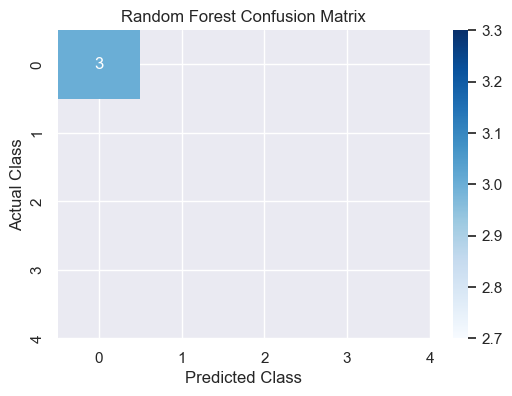

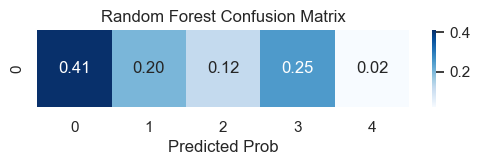

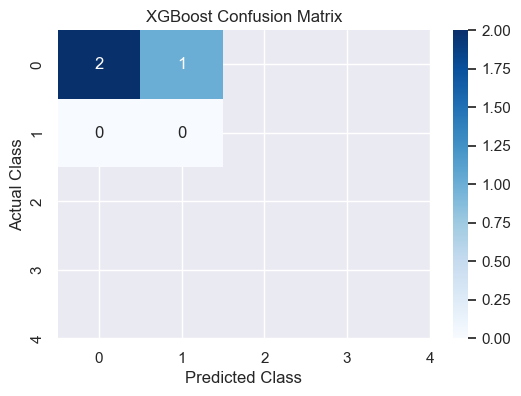

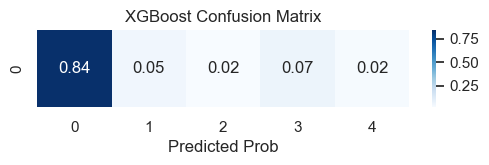

In [120]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [121]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [122]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [123]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

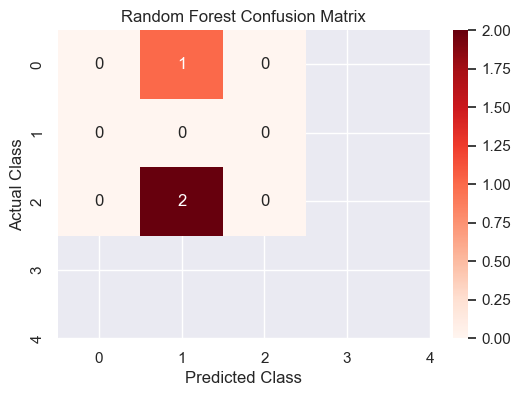

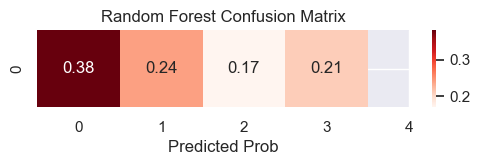

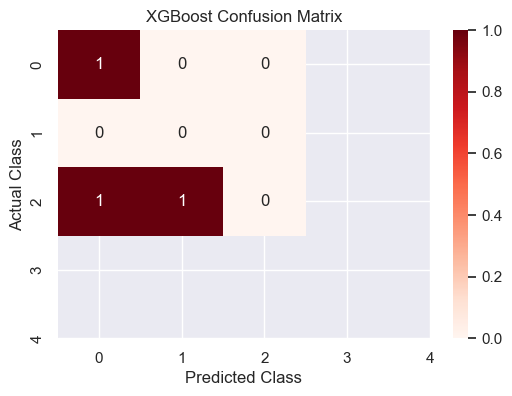

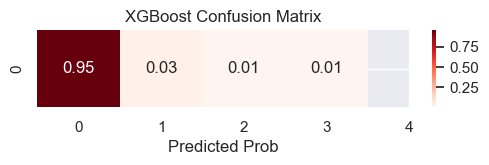

In [124]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [125]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [126]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [127]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

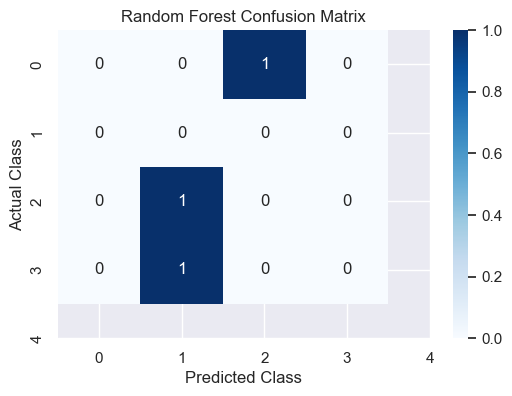

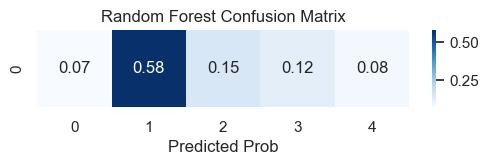

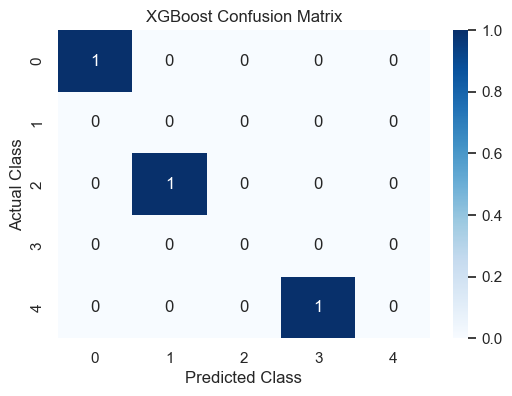

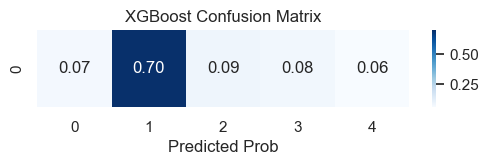

In [128]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [129]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [130]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [131]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

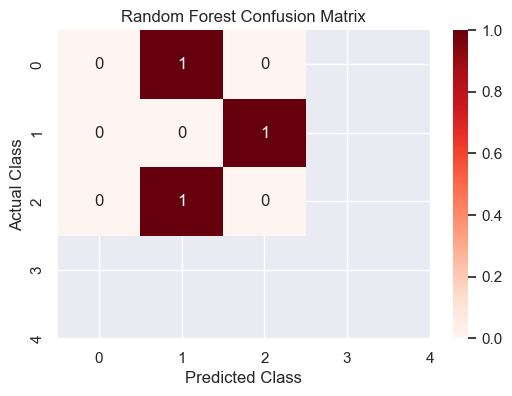

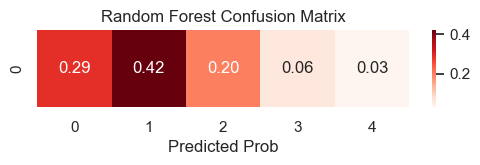

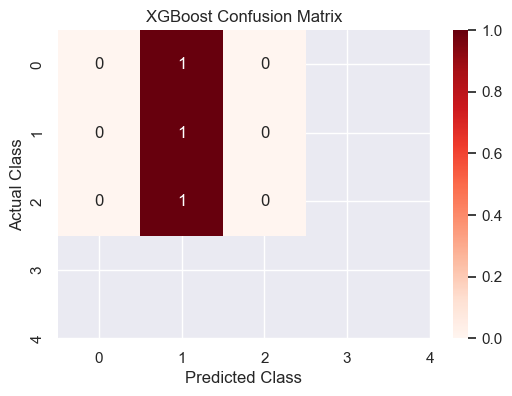

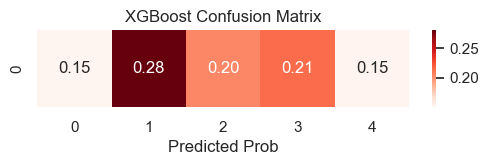

In [132]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

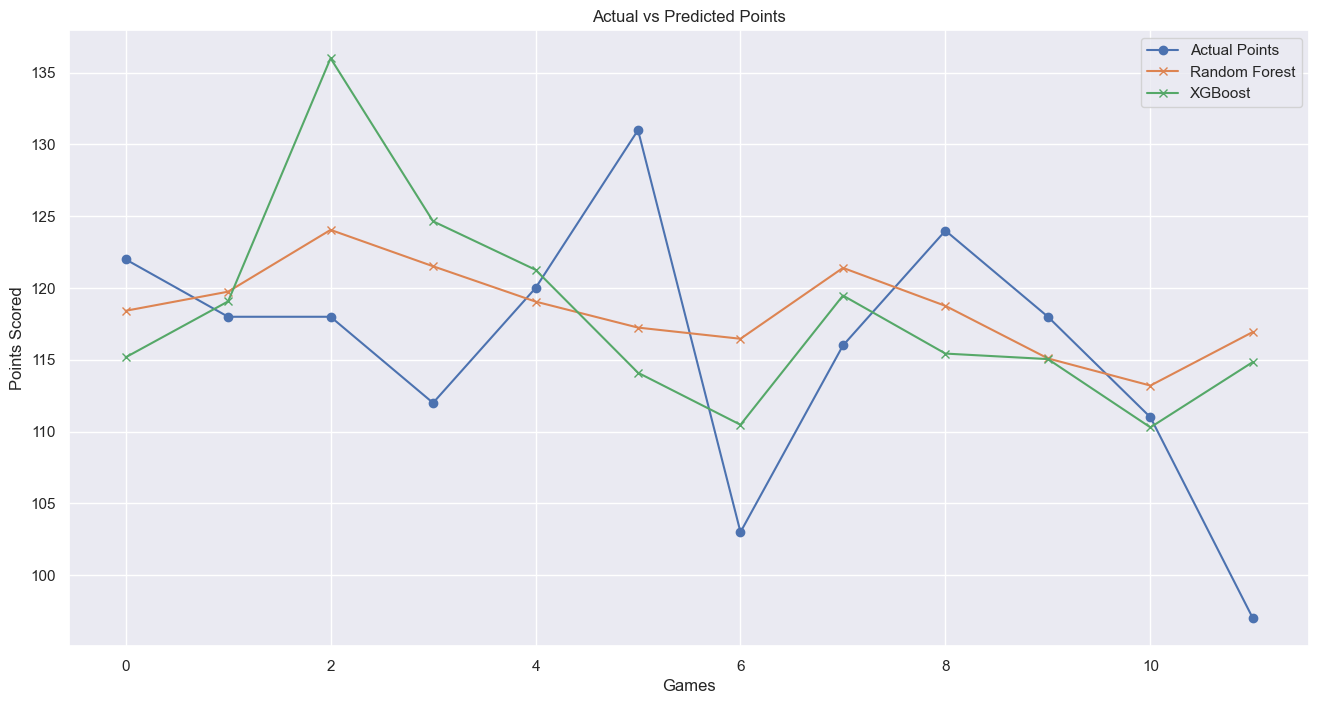

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
